In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import yaml
import pickle

In [3]:
TRACKING_URI = "http://localhost:5000"
EXPERIMENT_NAMES = ["leaf_size", "leaf_size__v2", "leaf_size__v4", "leaf_size_dali"]
PATH_OUT = Path.cwd().parents[1] / "results" / "leaf_size.csv"
DIR_FIGURES = Path.cwd().parents[1] / "results" / "leaf_size"
PATH_NAME_REPLACEMENTS_CONFIG = Path.cwd().parents[1] / "config" / "renaming.yml"
PATH_LOCAL_RCPARAMS = Path.cwd().parents[1] / "config" / "rc_params.yml"

In [4]:
plt.rcParams.update(plt.rcParamsDefault)
renaming = yaml.safe_load(PATH_NAME_REPLACEMENTS_CONFIG.read_text())
plt.rcParams.update(yaml.safe_load(PATH_LOCAL_RCPARAMS.read_text()))
plt.rcParams.update(
    {
        "legend.fontsize": 5,
    }
)

# \textwidth and \columnwidth in AAAI layout (printed by LaTeX)
TEXT_WIDTH = 7.00137
COLUMN_WIDTH = 3.31314
HALF_COLUMN_WIDTH = COLUMN_WIDTH / 2 - 0.001  # Some small margin

In [5]:
def fetch_runs(experiment_names) -> pd.DataFrame:
    """
    Fetches runs from MLflow tracking server for the specified experiments.
    Returns a DataFrame containing the runs.
    """
    import mlflow
    mlflow.set_tracking_uri(TRACKING_URI)
    return mlflow.search_runs(
        filter_string="attributes.status = 'FINISHED'",
        order_by=["start_time desc"],
        max_results=50_000,
        run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY,
        output_format="pandas",
        experiment_names=experiment_names,
    )

In [6]:
if PATH_OUT.exists():
    print(f"File {PATH_OUT} already exists. Loading existing data.")
    runs_df = pd.read_csv(PATH_OUT)
else:
    runs_df = fetch_runs(EXPERIMENT_NAMES)
    PATH_OUT.parent.mkdir(parents=True, exist_ok=True)
    runs_df.to_csv(PATH_OUT, index=False)

File c:\appsecurityexcluded\bipartite_forests_paper\experiments\results\leaf_size.csv already exists. Loading existing data.


In [7]:
metrics = runs_df.filter(like="metrics.")
metrics.columns = metrics.columns.str.removeprefix("metrics.")

df = runs_df.filter(items=["tags.estimator", "tags.dataset", "tags.validation_setting", "tags.fold_name"])
df.columns = df.columns.str.removeprefix("tags.")
df[["estimator", "leaf_size"]] = df["estimator"].str.rsplit("_", n=1, expand=True)
df = df.astype({"leaf_size": int})
other_columns = df.columns.to_list()

df = pd.concat([df, metrics], axis=1).drop_duplicates()

In [8]:
df = df.set_index(other_columns).rename_axis(columns="metric").stack().rename("value")
display(df)

estimator  dataset  validation_setting  fold_name  leaf_size  metric   
bgso       dpi_n    TT                  TT__15     100        LL__auprc    0.050000
                                                              LT__auroc    0.500000
                                                              LL__auroc    0.500000
                                                              TL__auprc    0.105691
                                                              TD__auroc    0.500000
                                                                             ...   
oxytrees   dpi_n    TT                  TT__3      2          LD__auroc    0.999049
                                                              LD__auprc    0.985515
                                                              TT__auroc    0.366667
                                                              LT__auprc    0.469649
                                                              TT__auprc    0.017241
Name

In [9]:
if df.index.duplicated(keep=False).any():
    print("There are duplicated indices in the DataFrame:")
    display(df.loc[df.index.duplicated(keep=False)].sort_index())
    df = df.loc[~df.index.duplicated(keep='first')]

There are duplicated indices in the DataFrame:


estimator  dataset  validation_setting  fold_name  leaf_size  metric   
bictr      davis    TT_75               TT_75__1   7          LD__auprc    0.190564
                                                              LD__auprc    0.200349
                                                              LD__auroc    0.919189
                                                              LD__auroc    0.923259
                                                              LL__auprc    0.286430
                                                                             ...   
oxytrees   npinter  TT_25               TT_25__2   6          TL__auroc    0.938520
                                                              TT__auprc    0.287436
                                                              TT__auprc    0.287436
                                                              TT__auroc    0.685461
                                                              TT__auroc    0.685461
Name

In [10]:
df = df.reset_index()

# Considering LT and TL together
df["masking_percent"] = df["validation_setting"].str.extract(r"_(\d+)$").astype(float).fillna(0)
df[["validation_setting", "metric"]] = df["metric"].str.rsplit("__", n=1, expand=True)

# The fold name will keep the original setting info
df["fold_name"] = df["validation_setting"] + "__" + df["fold_name"]
df = df.replace({"validation_setting": {"LT": "LT+TL", "TL": "LT+TL"}})

# Renaming
df = df.replace(
    {
        "estimator": renaming["estimator"],
        "dataset": renaming["dataset"],
        "metric": renaming["metric"],
        "validation_setting": renaming["validation_setting"],
    }
)

In [11]:
df = df.set_index(df.columns.drop("value").to_list())["value"]
df

estimator                dataset  validation_setting  fold_name     leaf_size  metric  masking_percent
Oxytrees[no leaf model]  DPI-N    Training            LL__TT__15    100        AUPRC   0.0                0.050000
                                  Semi-inductive      LT__TT__15    100        AUROC   0.0                0.500000
                                  Training            LL__TT__15    100        AUROC   0.0                0.500000
                                  Semi-inductive      TL__TT__15    100        AUPRC   0.0                0.105691
                                  Transductive        TD__TT__15    100        AUROC   0.0                0.500000
                                                                                                            ...   
Oxytrees                 DPI-N    LD                  LD__TT_50__0  2          AUROC   50.0               1.000000
                                                                               AUPRC   50.0 

In [12]:
normalized_df = df / df.xs(2, level="leaf_size")
display(normalized_df)

estimator                dataset     validation_setting  fold_name     leaf_size  metric  masking_percent
BICTR                    DPI-E       Inductive           TT__TT_25__0  100        AUPRC   25.0               0.127983
                                                                       50         AUPRC   25.0               0.122164
                                                                       20         AUPRC   25.0               0.305131
                                                                       15         AUPRC   25.0               0.334622
                                                                       14         AUPRC   25.0               0.347847
                                                                                                               ...   
Oxytrees[no leaf model]  miRTarBase  Transductive        TD__TT__3     6          AUROC   0.0                0.894887
                                                                    

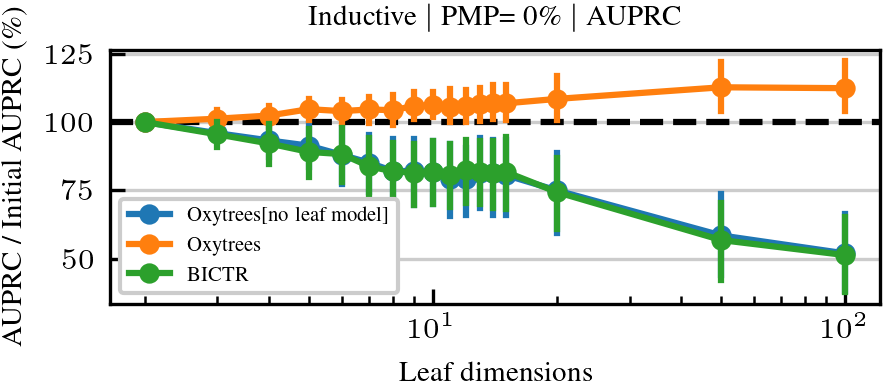

<Figure size 993.942x600 with 0 Axes>

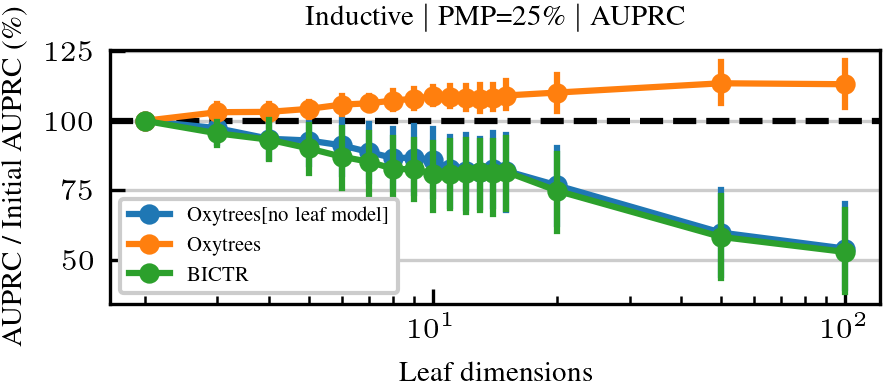

<Figure size 993.942x600 with 0 Axes>

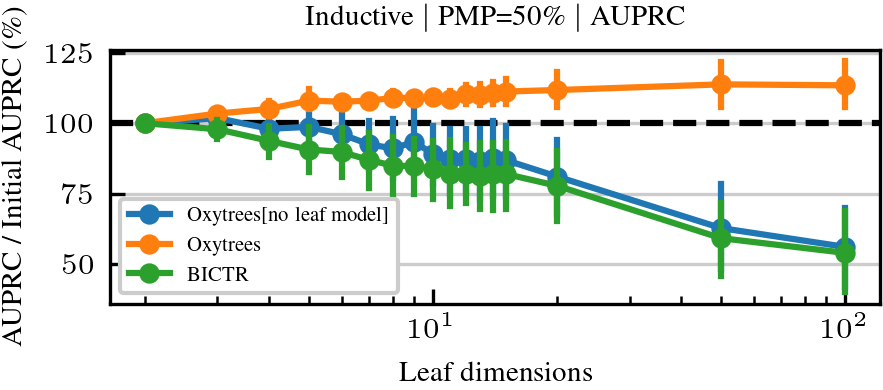

<Figure size 993.942x600 with 0 Axes>

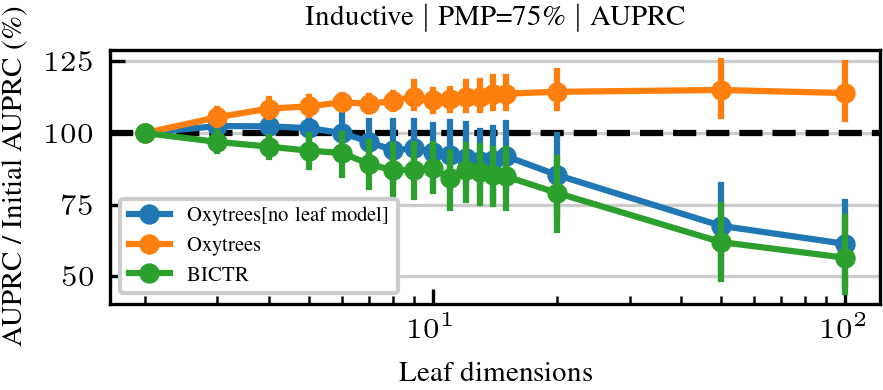

<Figure size 993.942x600 with 0 Axes>

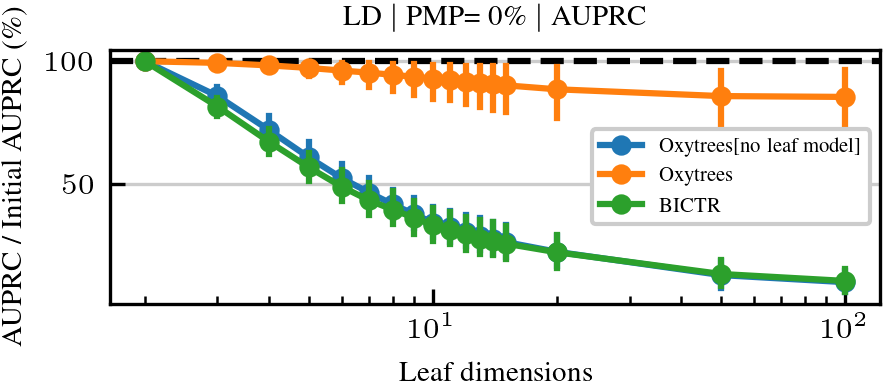

<Figure size 993.942x600 with 0 Axes>

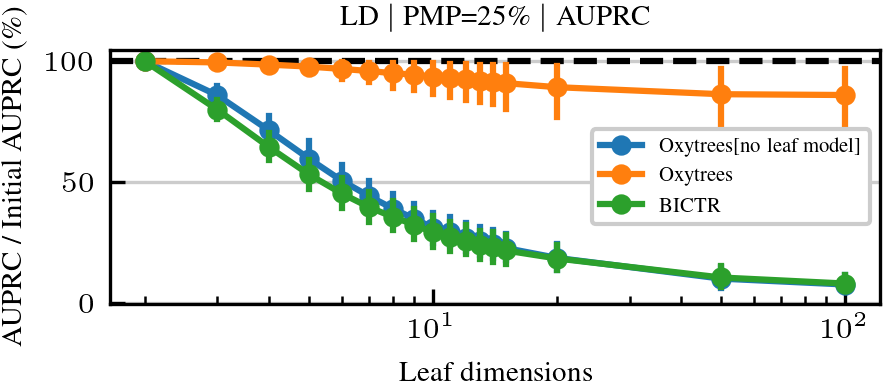

<Figure size 993.942x600 with 0 Axes>

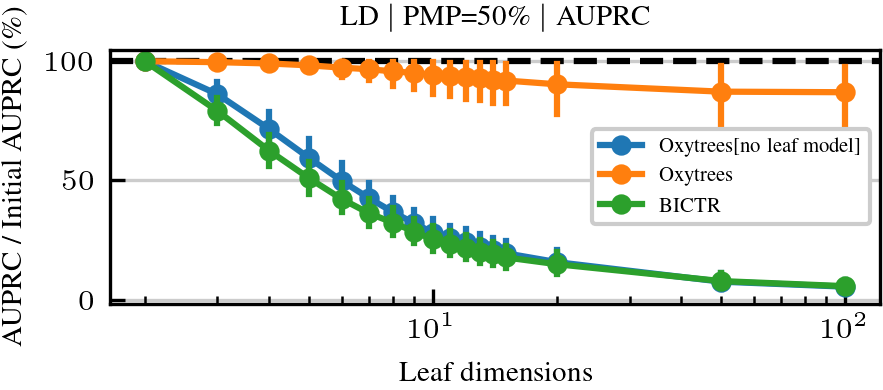

<Figure size 993.942x600 with 0 Axes>

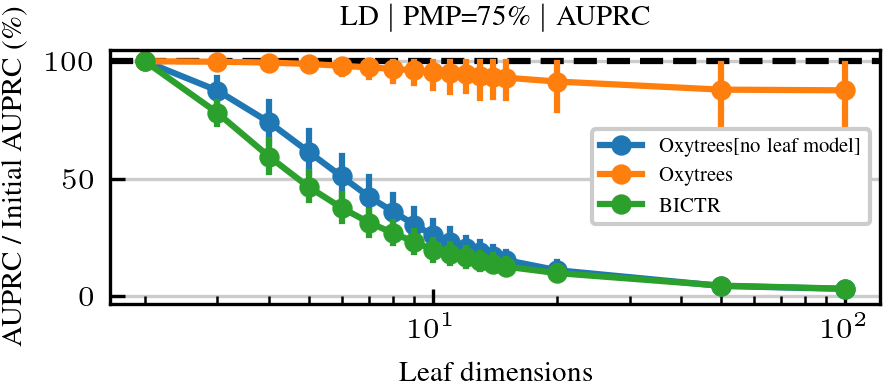

<Figure size 993.942x600 with 0 Axes>

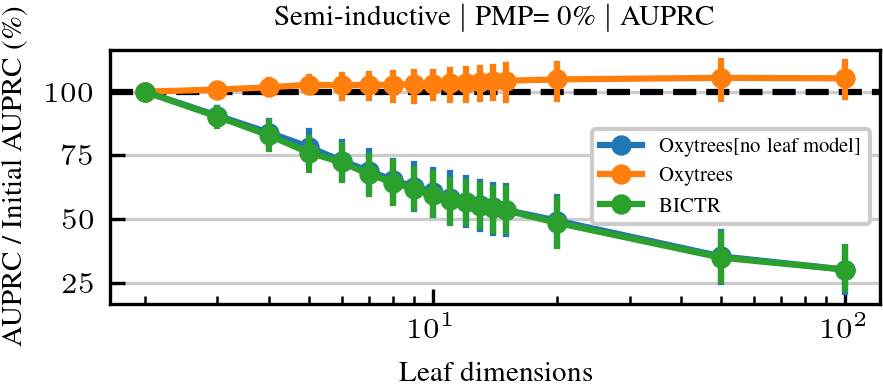

<Figure size 993.942x600 with 0 Axes>

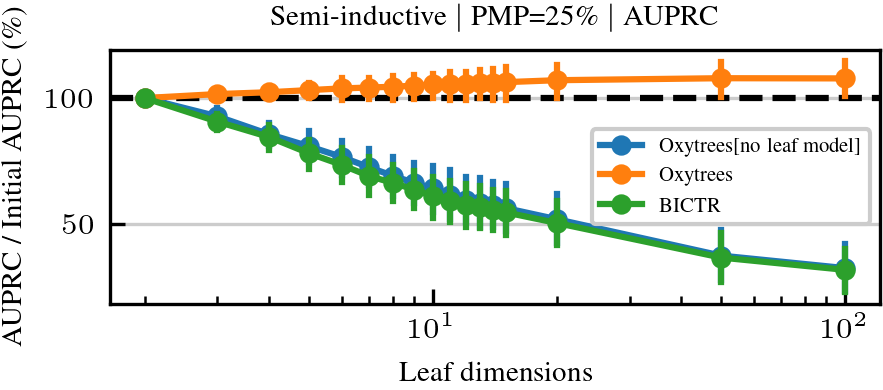

<Figure size 993.942x600 with 0 Axes>

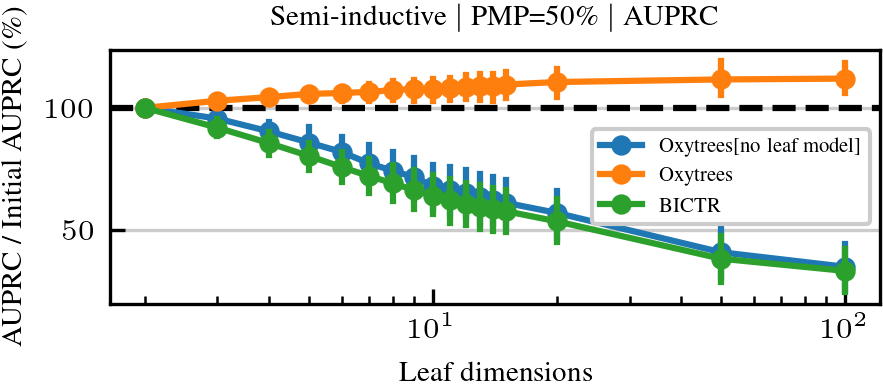

<Figure size 993.942x600 with 0 Axes>

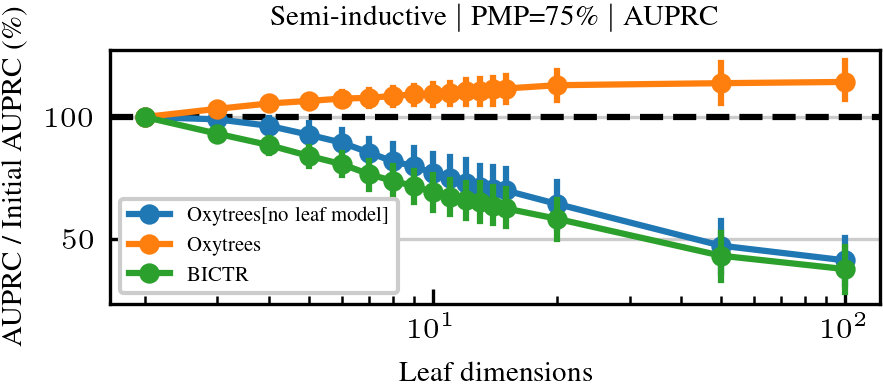

<Figure size 993.942x600 with 0 Axes>

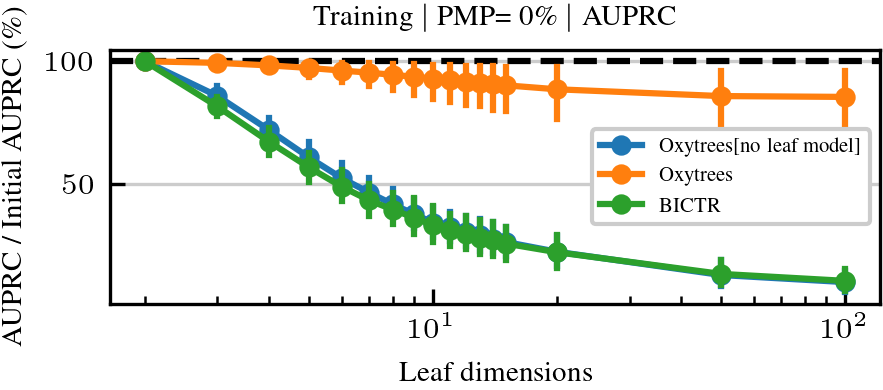

<Figure size 993.942x600 with 0 Axes>

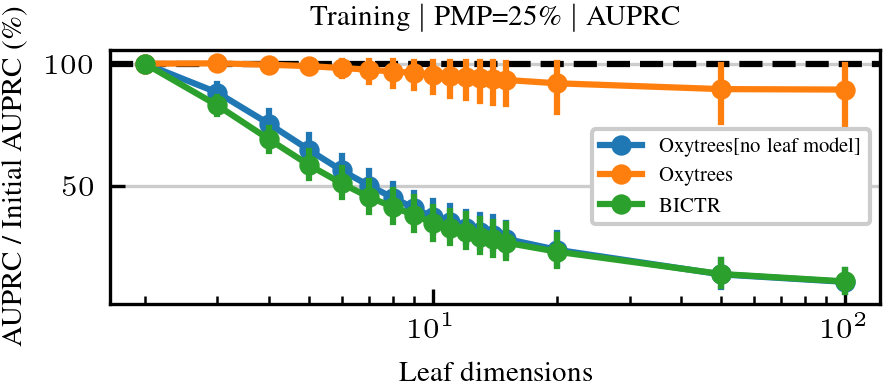

<Figure size 993.942x600 with 0 Axes>

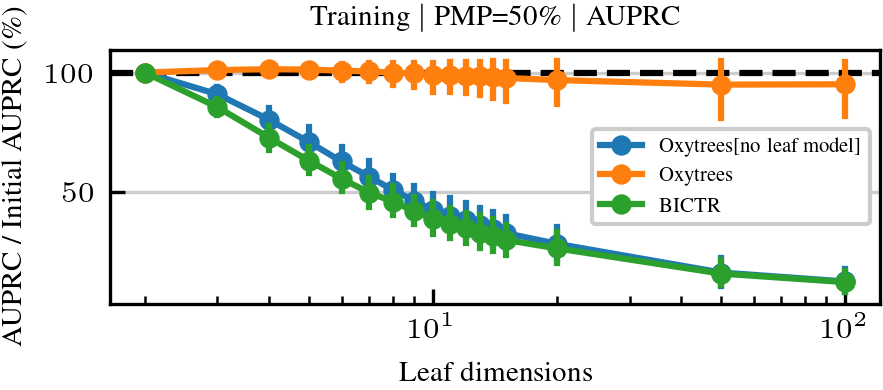

<Figure size 993.942x600 with 0 Axes>

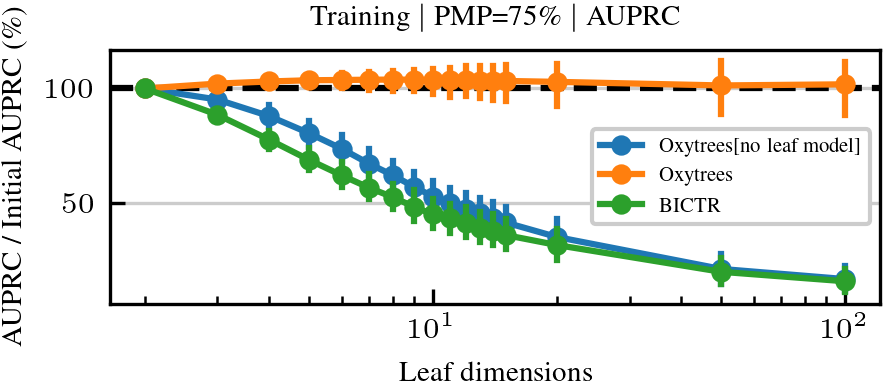

<Figure size 993.942x600 with 0 Axes>

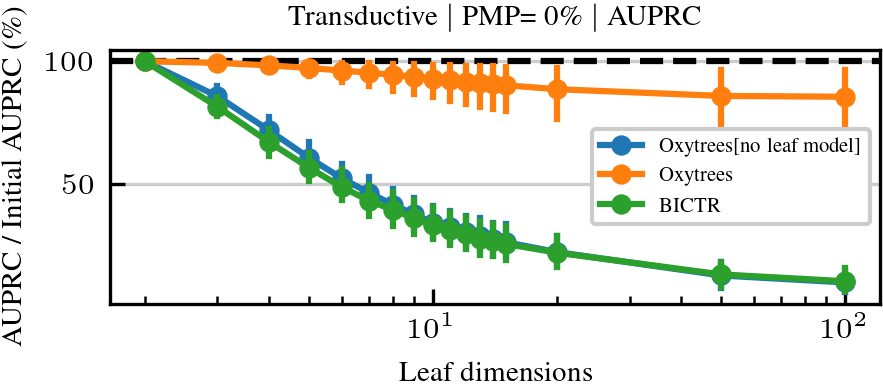

<Figure size 993.942x600 with 0 Axes>

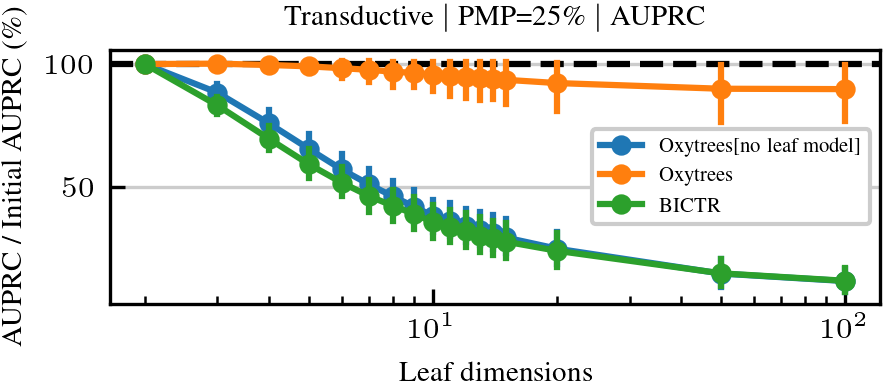

<Figure size 993.942x600 with 0 Axes>

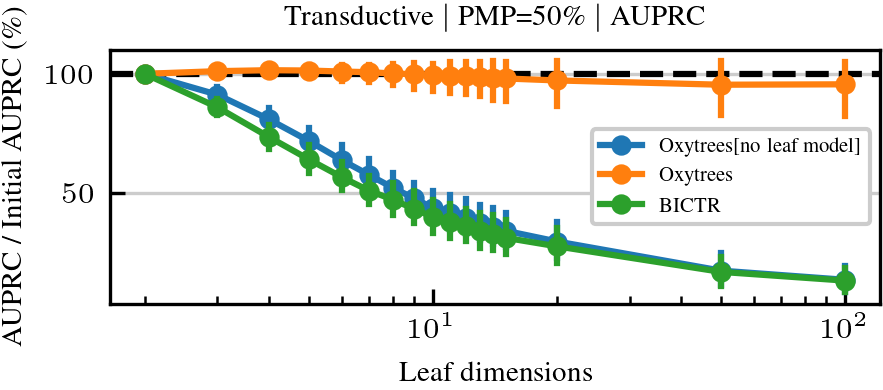

<Figure size 993.942x600 with 0 Axes>

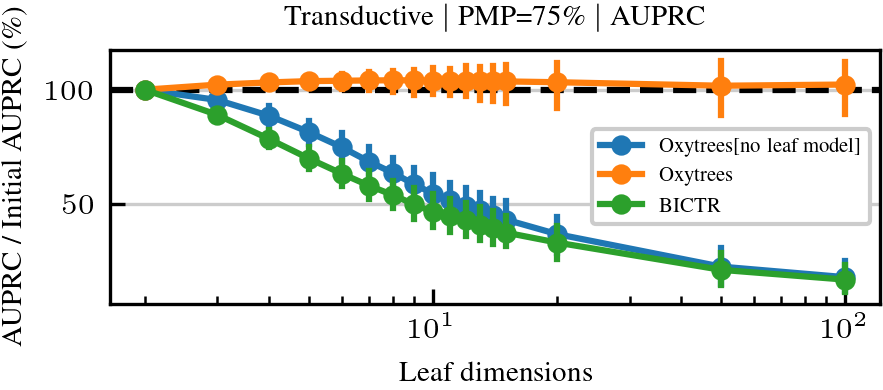

<Figure size 993.942x600 with 0 Axes>

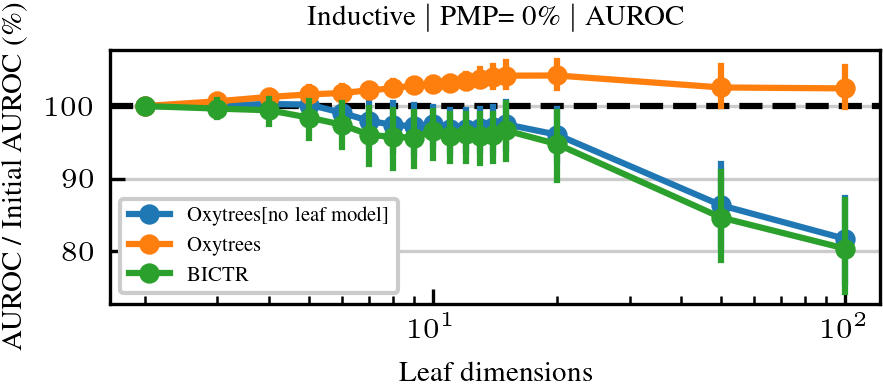

<Figure size 993.942x600 with 0 Axes>

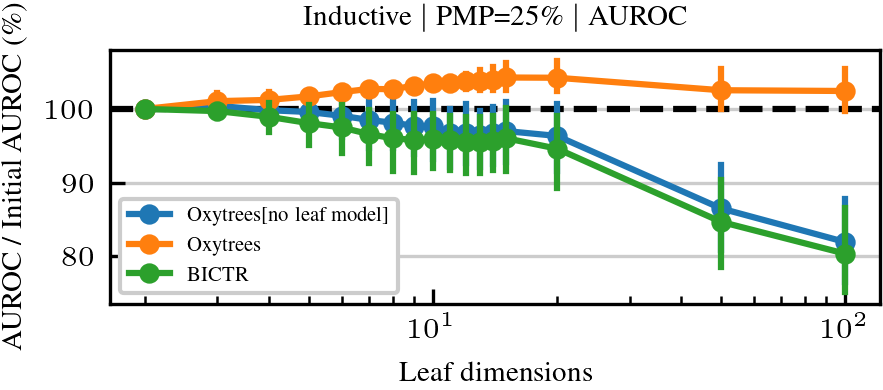

<Figure size 993.942x600 with 0 Axes>

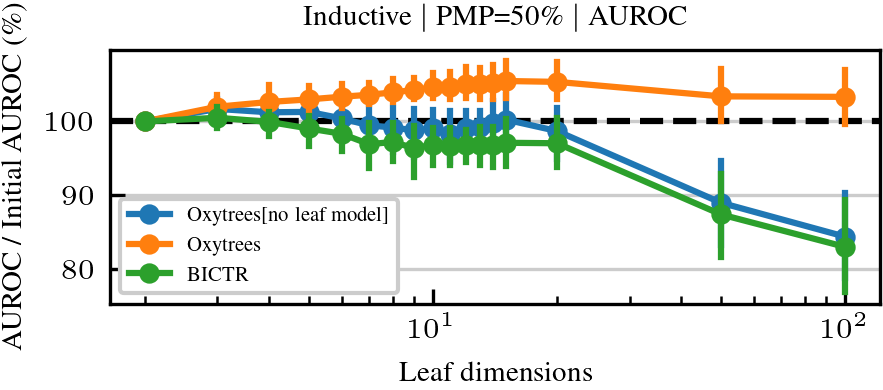

<Figure size 993.942x600 with 0 Axes>

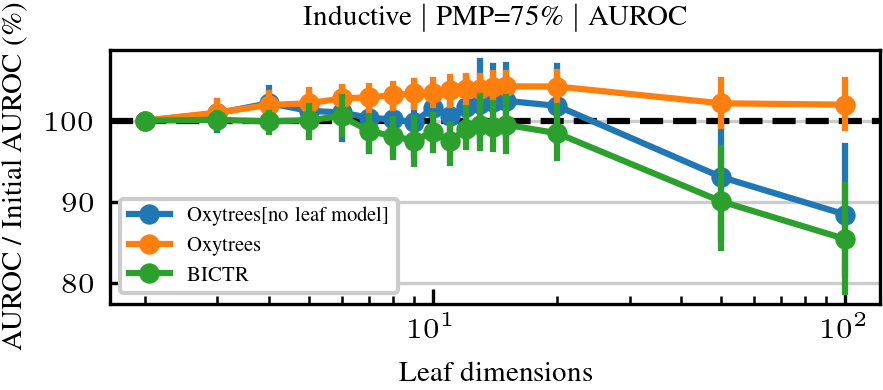

<Figure size 993.942x600 with 0 Axes>

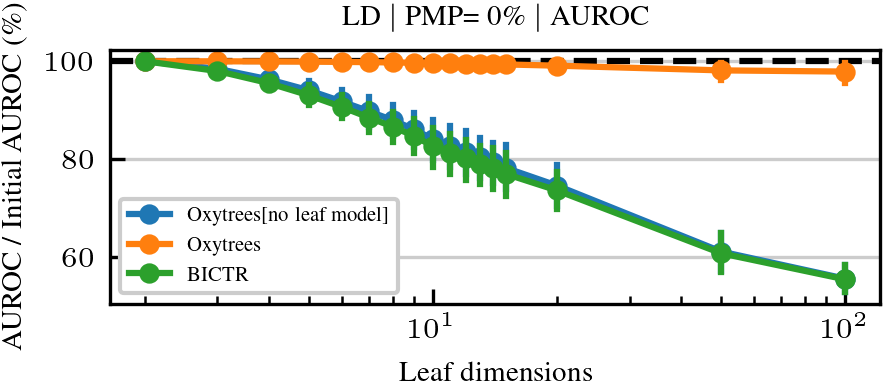

<Figure size 993.942x600 with 0 Axes>

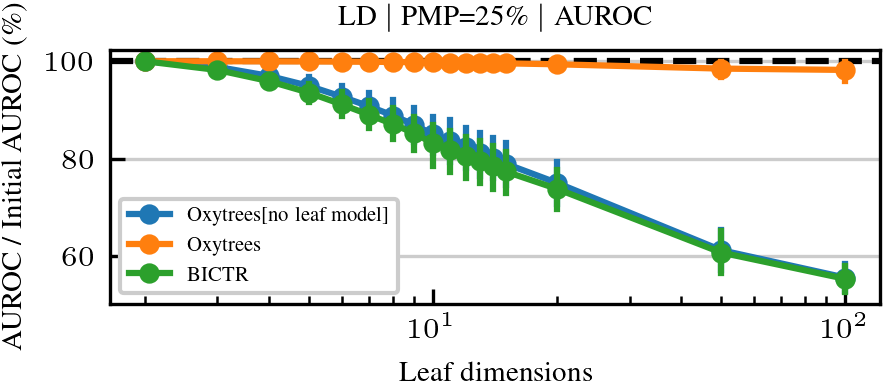

<Figure size 993.942x600 with 0 Axes>

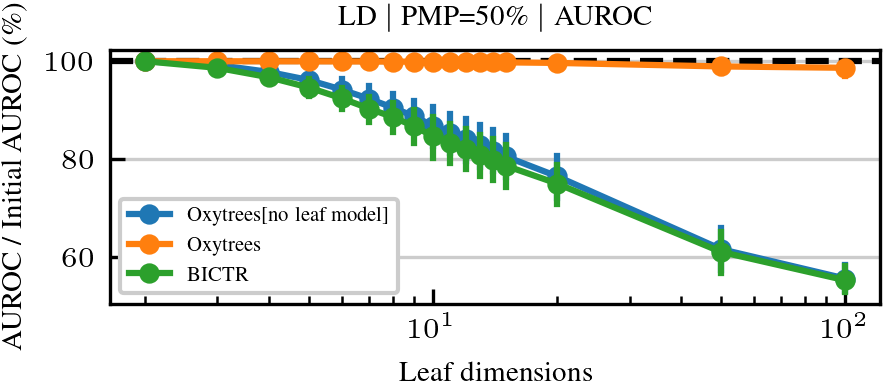

<Figure size 993.942x600 with 0 Axes>

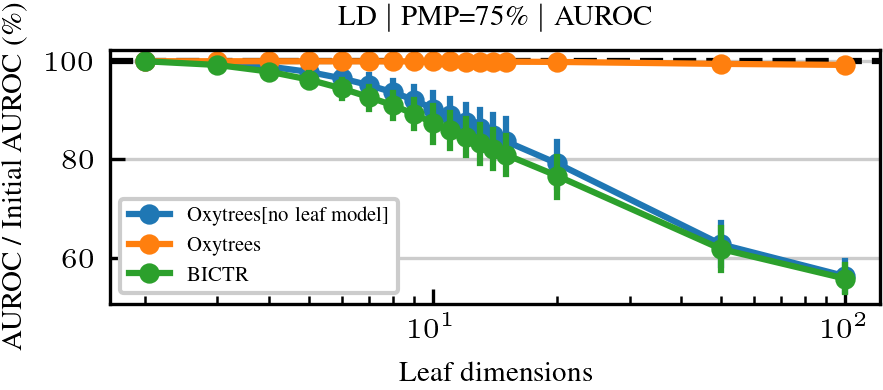

<Figure size 993.942x600 with 0 Axes>

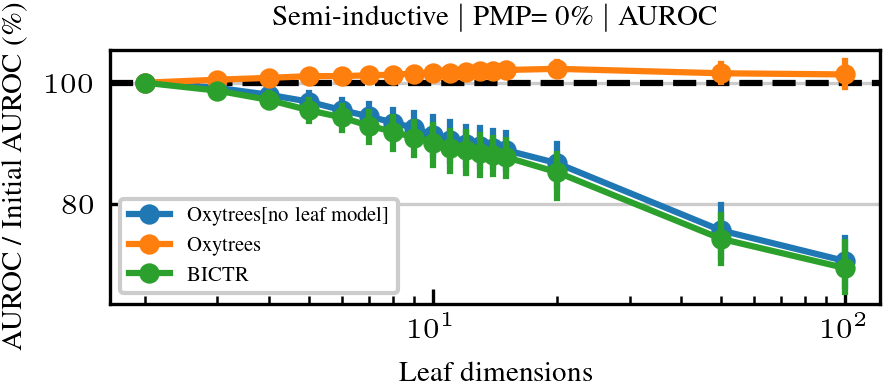

<Figure size 993.942x600 with 0 Axes>

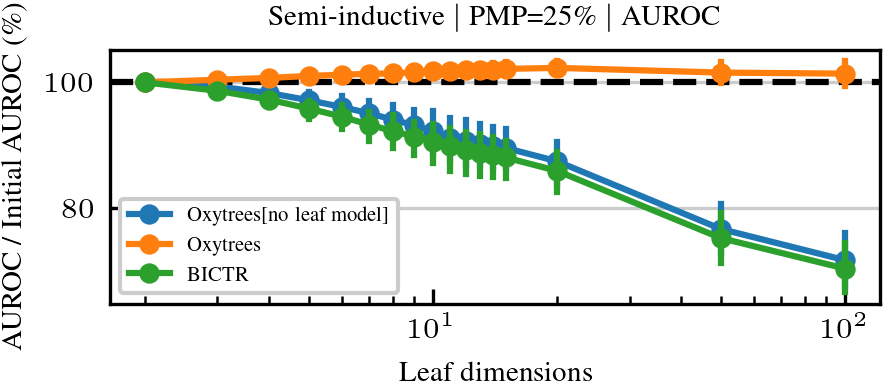

<Figure size 993.942x600 with 0 Axes>

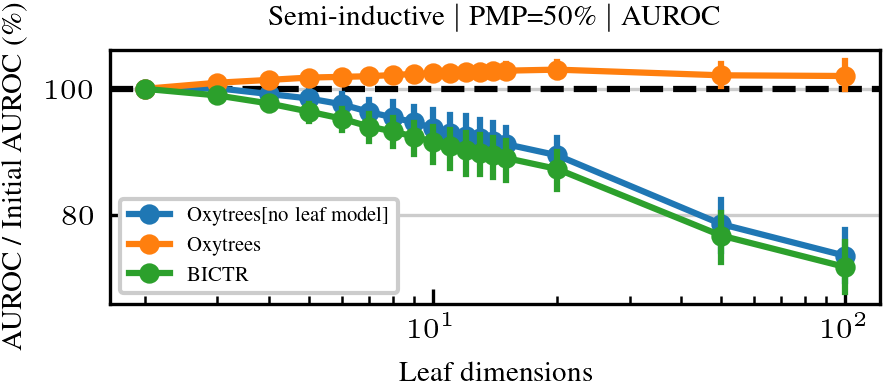

<Figure size 993.942x600 with 0 Axes>

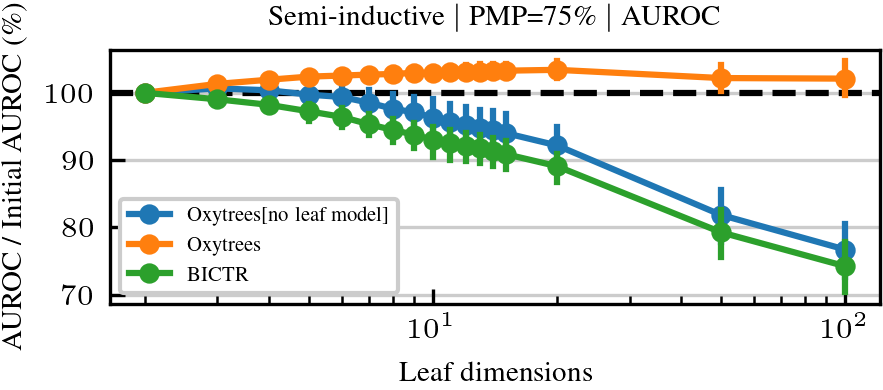

<Figure size 993.942x600 with 0 Axes>

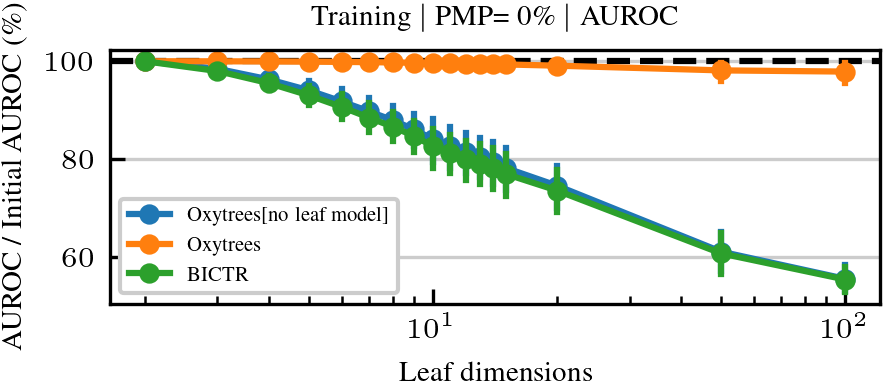

<Figure size 993.942x600 with 0 Axes>

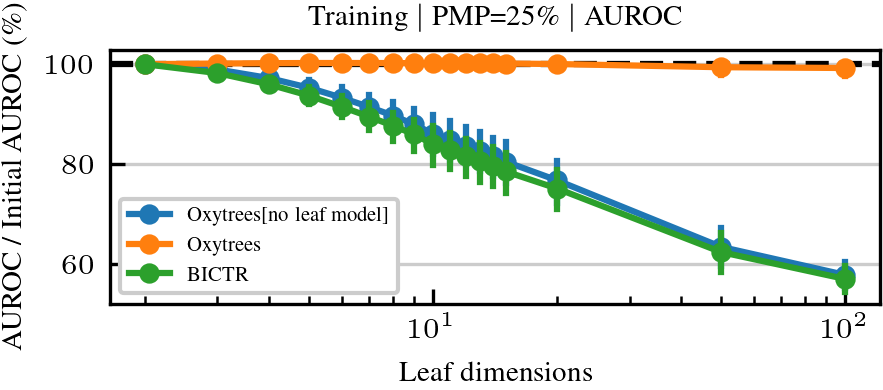

<Figure size 993.942x600 with 0 Axes>

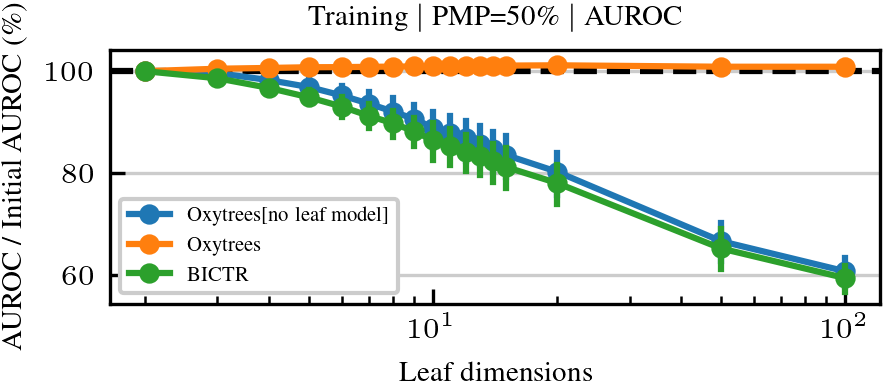

<Figure size 993.942x600 with 0 Axes>

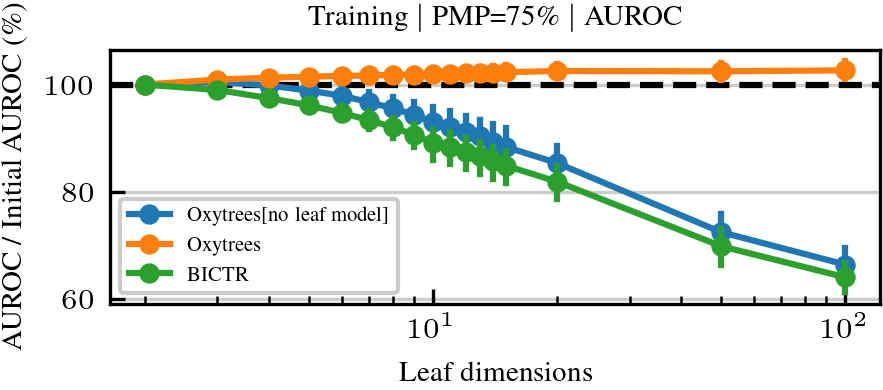

<Figure size 993.942x600 with 0 Axes>

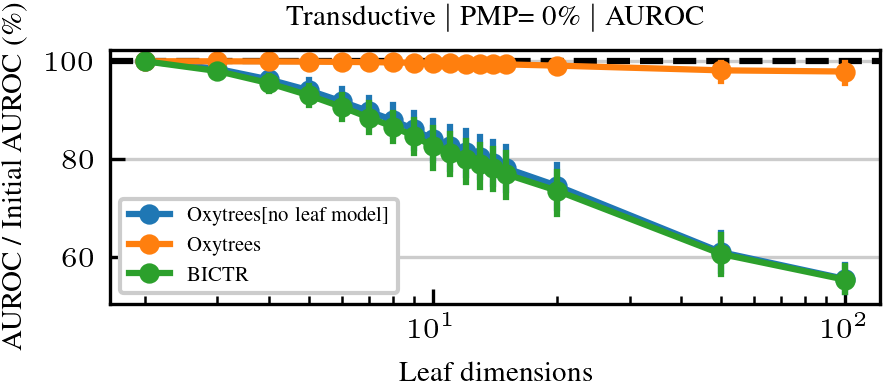

<Figure size 993.942x600 with 0 Axes>

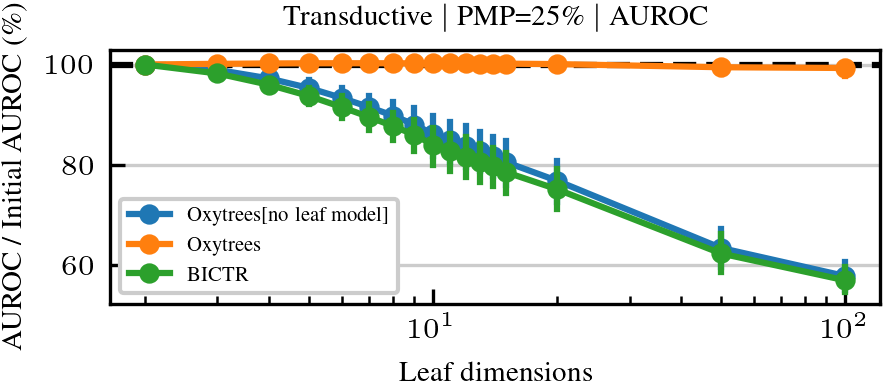

<Figure size 993.942x600 with 0 Axes>

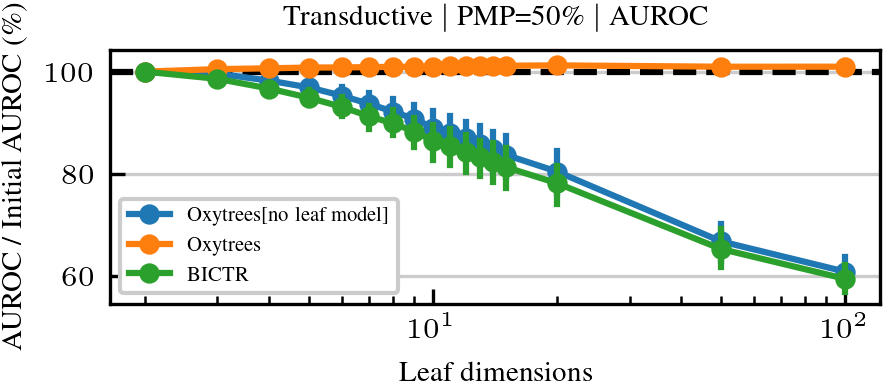

<Figure size 993.942x600 with 0 Axes>

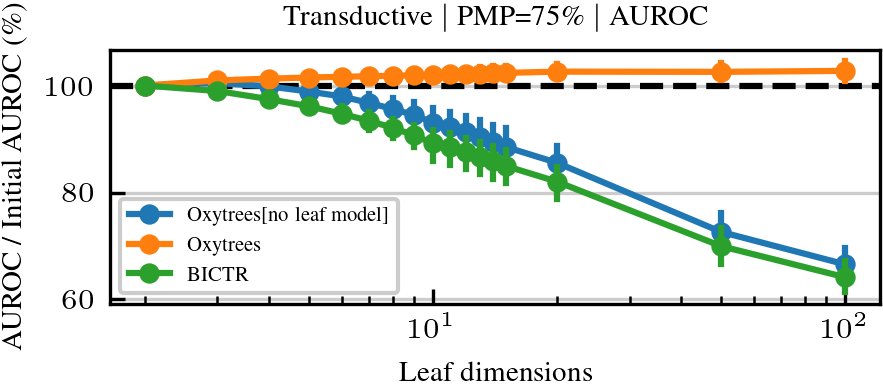

<Figure size 993.942x600 with 0 Axes>

In [13]:
figsize = (COLUMN_WIDTH, 1.1)
data_slice = normalized_df.copy()
# .xs("TT", level="validation_setting", drop_level=False).xs(
#     "TT__auroc", level="metric", drop_level=False
# )
data_slice *= 100  # Convert to percentage
data_slice = data_slice.groupby(data_slice.index.droplevel("fold_name").names).mean()

DIR_FIGURES.mkdir(parents=True, exist_ok=True)
TITLE_SEP = " $\\mid$ "

for name, group in data_slice.groupby(
    ["metric", "validation_setting", "masking_percent"]
):
    metric, validation_setting, masking_percent = name

    plt.figure(figsize=figsize)
    # sns.scatterplot(x="leaf_size", y="value", hue="estimator", data=group.reset_index())
    # plt.xscale("log")
    sns.pointplot(
        data=group.reset_index(),
        x="leaf_size",
        y="value",
        hue="estimator",
        hue_order=map(renaming["estimator"].get, ["bgso", "oxytrees", "bictr"]),
        linewidth=1.5,
        native_scale=True,
    )
    plt.xscale("log")
    plt.xlabel(f"Leaf dimensions")
    plt.ylabel(f"{metric} / Initial {metric} (\\%)")
    plt.title(
        TITLE_SEP.join(
            (
                validation_setting,
                f"PMP={masking_percent:2.0f}\\%",
                metric,
            )
        )
    )

    # plt.xticks(rotation=45)
    plt.grid(axis="y", zorder=-2)
    plt.axhline(y=100, color="black", linestyle="--", zorder=0)
    # plt.legend().set_visible(False)
    plt.legend().set_title(None)
    path_out = DIR_FIGURES / f"{validation_setting}_{metric}_{masking_percent:02.0f}.pdf"
    plt.savefig(path_out)

    with path_out.with_suffix(".pickle").open("wb") as f:
        pickle.dump(plt.gcf(), f)

    plt.show()
    plt.clf()